# 13F holdings analysis

Institutional investment managers report their holdings quarterly on
Form 13F. This notebook pulls one manager's latest portfolio, asks the
opposite question (who are the biggest reported holders of one stock?),
then scales the idea up to a manager similarity matrix.

Needs `pandas` and `matplotlib`, and a free API key in
`THREESPREAD_API_KEY` ([signup](https://3spread.com/auth/signup)).

In [1]:
import pandas as pd

from py3spread import Client

client = Client()

MANAGER_CIK = "1067983"  # berkshire hathaway

filing = client.institutional_holdings.list(filing_manager_cik=MANAGER_CIK, limit=1)["data"][0]
print(f"{filing['filer_name']}, period {filing['period_of_report']}")

holdings = pd.DataFrame(
    client.institutional_holdings.iter_holdings(filing_id=filing["filing_id"])
)
holdings["value_usd"] = pd.to_numeric(holdings["value_usd"])
holdings["ssh_prnamt"] = pd.to_numeric(holdings["ssh_prnamt"])
print(f"{len(holdings)} positions, ${holdings['value_usd'].sum():,.0f} reported value")
holdings[["name_of_issuer", "title_of_class", "ssh_prnamt", "value_usd"]].head()

BERKSHIRE HATHAWAY INC, period 2026-03-31
90 positions, $263,095,703,570 reported value


,name_of_issuer,title_of_class,ssh_prnamt,value_usd
0,ALLY FINL INC,COM,12719675.0,498992850.0
1,ALLY FINL INC,COM,2803875.0,109996016.0
2,ALLY FINL INC,COM,4228200.0,165872286.0
3,ALLY FINL INC,COM,3137000.0,123064510.0
4,ALLY FINL INC,COM,4836250.0,189726088.0


## Top positions

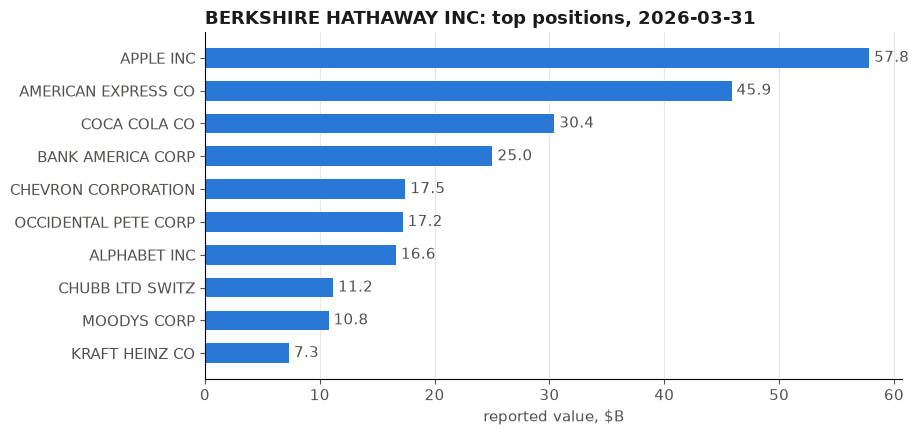

In [2]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (9, 4.5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#e8e7e2",
    "grid.linewidth": 0.8,
    "axes.axisbelow": True,
    "font.size": 11,
    "text.color": "#1a1a19",
    "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
})
BLUE = "#2a78d6"
INK = "#52514e"


top = (holdings.groupby("name_of_issuer")["value_usd"].sum()
    .sort_values().tail(10) / 1e9)

fig, ax = plt.subplots()
ax.barh(top.index, top.values, color=BLUE, height=0.6)
ax.set_title(f"{filing['filer_name']}: top positions, {filing['period_of_report']}",
             loc="left", fontweight="bold")
ax.set_xlabel("reported value, $B")
ax.grid(axis="y", visible=False)
for i, v in enumerate(top.values):
    ax.text(v, i, f" {v:,.1f}", va="center", color="#52514e")
plt.show()

## Who holds a stock

The holdings stream also works the other way: filter by CUSIP to see every
manager's reported position. `min_value` keeps it to large holders and
`period` pins one quarter so managers appear once.

In [3]:
PERIOD = filing["period_of_report"]

holders = pd.DataFrame(client.institutional_holdings.holdings(
    cusip="037833100",  # apple
    period=PERIOD,
    min_value=1_000_000_000,
    sort="value",
    order="desc",
    limit=15,
)["data"])
holders["value_usd"] = pd.to_numeric(holders["value_usd"])
holders["ssh_prnamt"] = pd.to_numeric(holders["ssh_prnamt"])
(holders[["filing_manager_name", "ssh_prnamt", "value_usd"]]
    .style.format({"value_usd": "${:,.0f}", "ssh_prnamt": "{:,.0f}"}))

,filing_manager_name,ssh_prnamt,value_usd
0,VANGUARD CAPITAL MANAGEMENT LLC,"953,847,648","$241,720,924,860"
1,STATE STREET CORP,"602,341,409","$152,868,226,190"
2,"BlackRock, Inc.","423,910,689","$107,584,293,761"
3,VANGUARD PORTFOLIO MANAGEMENT LLC,"331,437,055","$84,115,410,189"
4,"GEODE CAPITAL MANAGEMENT, LLC","323,493,099","$81,852,564,204"
5,"BlackRock, Inc.","301,958,751","$76,634,111,416"
6,FMR LLC,"194,238,987","$49,295,912,309"
7,PRICE T ROWE ASSOCIATES INC /MD/,"179,340,662","$45,514,867,000"
8,JPMORGAN CHASE & CO,"148,968,379","$36,740,071,335"
9,"BlackRock, Inc.","125,630,739","$31,883,825,251"


## Which managers actually differ

Scale the two-manager overlap idea (see `fund_overlap.ipynb`) to ten
managers at once: the big holders above plus Berkshire. Pairwise overlap
is the sum over common positions of the smaller portfolio weight, so
identical books score 100 and disjoint books score 0.

In [4]:
import itertools

CAP = 2000  # largest positions per manager, plenty for weight overlap

managers = {}
for h in holders.itertuples():
    managers.setdefault(h.filing_manager_cik, h.filing_manager_name)
managers = dict(list(managers.items())[:9])
managers[MANAGER_CIK] = "BERKSHIRE HATHAWAY"


def weight_series(cik):
    latest = client.institutional_holdings.list(filing_manager_cik=cik, limit=1)["data"][0]
    rows = itertools.islice(
        client.institutional_holdings.iter_holdings(
            filing_id=latest["filing_id"], sort="value", order="desc", limit=500),
        CAP,
    )
    s = (pd.DataFrame(rows)
         .assign(value_usd=lambda d: pd.to_numeric(d["value_usd"]))
         .groupby("cusip")["value_usd"].sum())
    return s / s.sum()


portfolios = {name: weight_series(cik) for cik, name in managers.items()}
print("loaded", len(portfolios), "portfolios")

loaded 10 portfolios


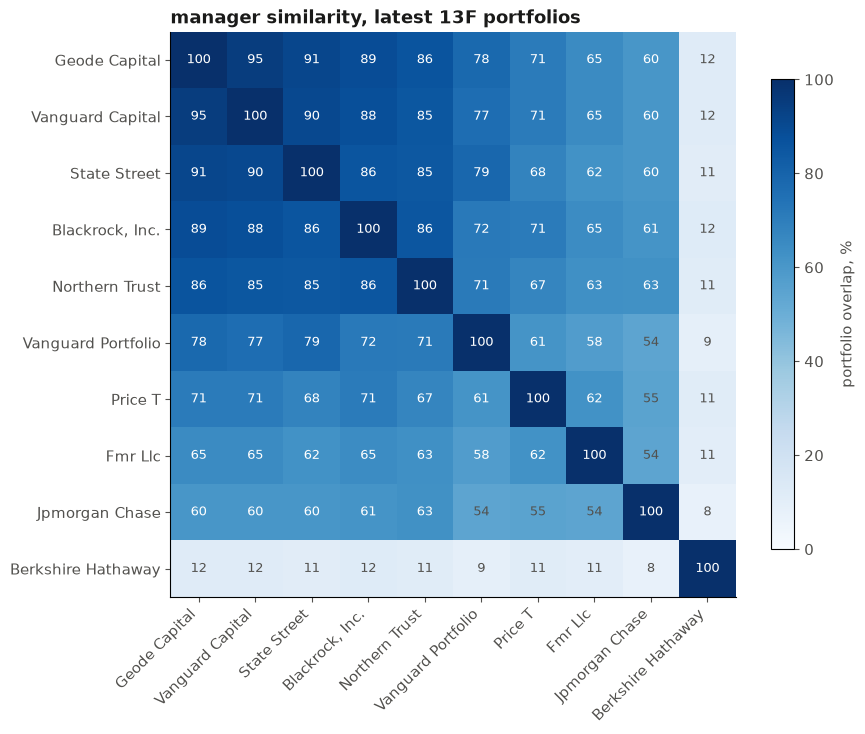

In [5]:
import numpy as np

names = list(portfolios)
n = len(names)
overlap = np.eye(n) * 100
for i in range(n):
    for j in range(i + 1, n):
        a, b = portfolios[names[i]], portfolios[names[j]]
        common = a.index.intersection(b.index)
        overlap[i, j] = overlap[j, i] = float(np.minimum(a[common], b[common]).sum()) * 100

# greedy nearest-neighbor ordering so similar managers sit together
order = [int(np.argmax(overlap.sum(axis=1)))]
while len(order) < n:
    rest = [k for k in range(n) if k not in order]
    order.append(max(rest, key=lambda k: overlap[order[-1], k]))

m = overlap[np.ix_(order, order)]
labels = [" ".join(names[k].title().split()[:2]) for k in order]

fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(m, cmap="Blues", vmin=0, vmax=100)
ax.set_xticks(range(n), labels, rotation=45, ha="right")
ax.set_yticks(range(n), labels)
ax.grid(visible=False)
for i in range(n):
    for j in range(n):
        ax.text(j, i, f"{m[i, j]:.0f}", ha="center", va="center", fontsize=9,
                color="white" if m[i, j] > 55 else INK)
fig.colorbar(im, ax=ax, shrink=0.8, label="portfolio overlap, %")
ax.set_title("manager similarity, latest 13F portfolios", loc="left", fontweight="bold")
plt.tight_layout()
plt.show()

The custodian and index complex clusters tightly (they all hold the
market), while concentrated active books sit in their own rows. The
diagonal is 100 by definition. Swap in any manager CIKs, or loop the
matrix over time to watch a manager drift toward or away from the
index.